# 🧠 Regressão Logística Aplicada do Zero

Neste notebook, aplicaremos o algoritmo de **Regressão Logística** implementado de forma 100% nativa na nossa suíte local para resolver um problema clássico de **Classificação Binária** (Aprovado vs. Reprovado).

---

## 🎯 Objetivo
Prever a probabilidade de aprovação de um aluno com base nas horas de estudo, calibrando o peso ($w$) e o viés ($b$) através do Gradiente Descendente, e avaliando a qualidade do modelo com as métricas de classificação importadas da nossa biblioteca local.

In [1]:
import sys
import os

# Adiciona o diretório raiz ao path do Python para importar as bibliotecas locais
sys.path.append(os.path.abspath('..'))

import algebra as alg
import estatistica as est
import machine_learning as ml

## 1. O Problema e os Dados

Vamos simular o desempenho de 20 alunos. Nosso objetivo é classificar os alunos em duas categorias:
* **0 (Reprovado)**: Alunos que não atingiram a nota de corte.
* **1 (Aprovado)**: Alunos que atingiram a nota de corte.

Nossa única característica preditiva ($X$) é a quantidade de **horas de estudo**.

In [2]:
# Dados de treino sintéticos
X = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.2, 4.5, 4.8, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 10.0]
y = [0,   0,   0,   0,   0,   0,   0,   0,   1,   0,   1,   0,   1,   1,   1,   1,   1,   1,   1,   1]

print(f"Total de amostras: {len(X)}")
print(f"Alunos aprovados (1): {sum(y)}")
print(f"Alunos reprovados (0): {len(y) - sum(y)}")

Total de amostras: 20
Alunos aprovados (1): 10
Alunos reprovados (0): 10


## 2. Ajuste do Modelo (Treinamento)

Usaremos a função `treinar_logistica` do módulo `machine_learning.py` para calibrar o peso ($w$) e o bias ($b$).
Sob o capô, a função inicializa $w = 0$ e $b = 0$, calculando os erros usando a nossa sigmoide estável e aplicando o Gradiente Descendente para minimizar a perda de entropia cruzada (*Log Loss*).

In [3]:
# Treinando o modelo via classe unificada
taxa_aprendizado = 0.2
epocas = 5000

modelo_logistica = ml.RegressaoLogistica().fit(X, y, taxa_aprendizado, epocas)
peso = modelo_logistica.peso
bias = modelo_logistica.bias

print("=== Modelo Ajustado ===")
print(f"Peso Calibrado (w): {peso:.6f}")
print(f"Bias Calibrado (b): {bias:.6f}")

=== Modelo Ajustado ===
Peso Calibrado (w): 1.873204
Bias Calibrado (b): -9.412887


## 3. A Fronteira de Decisão e Interpretação Matemática

A nossa previsão de probabilidade é dada por:
$$P(Y = 1 | x) = \sigma(w \cdot x + b)$$

O limiar de decisão clássico é de **50%**. Isso significa que o aluno é classificado como aprovado se a probabilidade for $\ge 0.5$.
Matematicamente, a fronteira de decisão (onde a probabilidade é exatamente 0.5) ocorre quando o termo linear é nulo:
$$w \cdot x + b = 0 \implies x_{\text{fronteira}} = -\frac{b}{w}$$

Vamos calcular esse ponto:

In [4]:
fronteira = -bias / peso
print(f"Fronteira de Decisão calculada: {fronteira:.4f} horas de estudo.")
print(f"Estudar mais de {fronteira:.2f}h prevê aprovação (Probabilidade > 50%).")

Fronteira de Decisão calculada: 5.0250 horas de estudo.
Estudar mais de 5.03h prevê aprovação (Probabilidade > 50%).


## 4. Visualização Gráfica do Ajuste

Utilizaremos o `matplotlib` para desenhar os dados reais e a curva sigmoide que o nosso modelo aprendeu, destacando o ponto da fronteira de decisão.

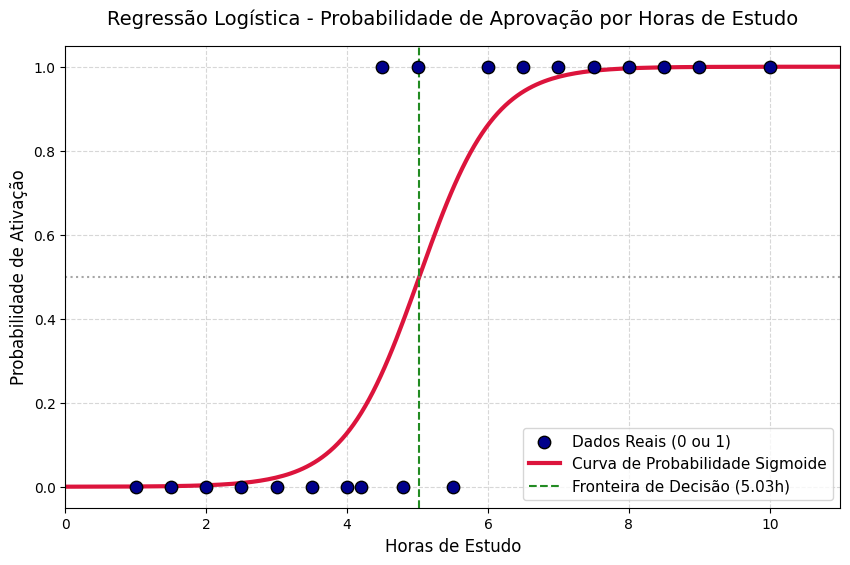

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Gerar pontos para traçar a curva sigmoide suave
X_curva = np.linspace(0, 11, 200)
y_curva = ml.realizar_previsao(X_curva, peso, bias, modelo="logistica")

plt.figure(figsize=(10, 6))

# Plotar pontos reais
plt.scatter(X, y, color='darkblue', edgecolor='k', s=80, label='Dados Reais (0 ou 1)', zorder=3)

# Plotar curva Sigmoide ajustada
plt.plot(X_curva, y_curva, color='crimson', linewidth=3, label='Curva de Probabilidade Sigmoide', zorder=2)

# Linha da fronteira de decisão (50%)
plt.axvline(x=fronteira, color='forestgreen', linestyle='--', label=f'Fronteira de Decisão ({fronteira:.2f}h)')
plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.7)

plt.title('Regressão Logística - Probabilidade de Aprovação por Horas de Estudo', fontsize=14, pad=15)
plt.xlabel('Horas de Estudo', fontsize=12)
plt.ylabel('Probabilidade de Ativação', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=11)
plt.xlim(0, 11)
plt.ylim(-0.05, 1.05)

plt.show()

## 5. Visualizando a Evolução dos Logits ($z_i$) e Probabilidades ao Longo do Treinamento

Para observar a conversão de $z_i = w \cdot x_i + b$ dentro da função sigmoide $\sigma(z_i)$ ao longo das 5000 iterações, recriamos o loop de treinamento para extrair fotografias dos pesos nas épocas 0, 50, 200, 1000 e 5000. 

No gráfico abaixo, o eixo horizontal é o valor do logit linear $z$ e o eixo vertical é a probabilidade resultante. A curva sigmoide em cinza serve de referência estática.

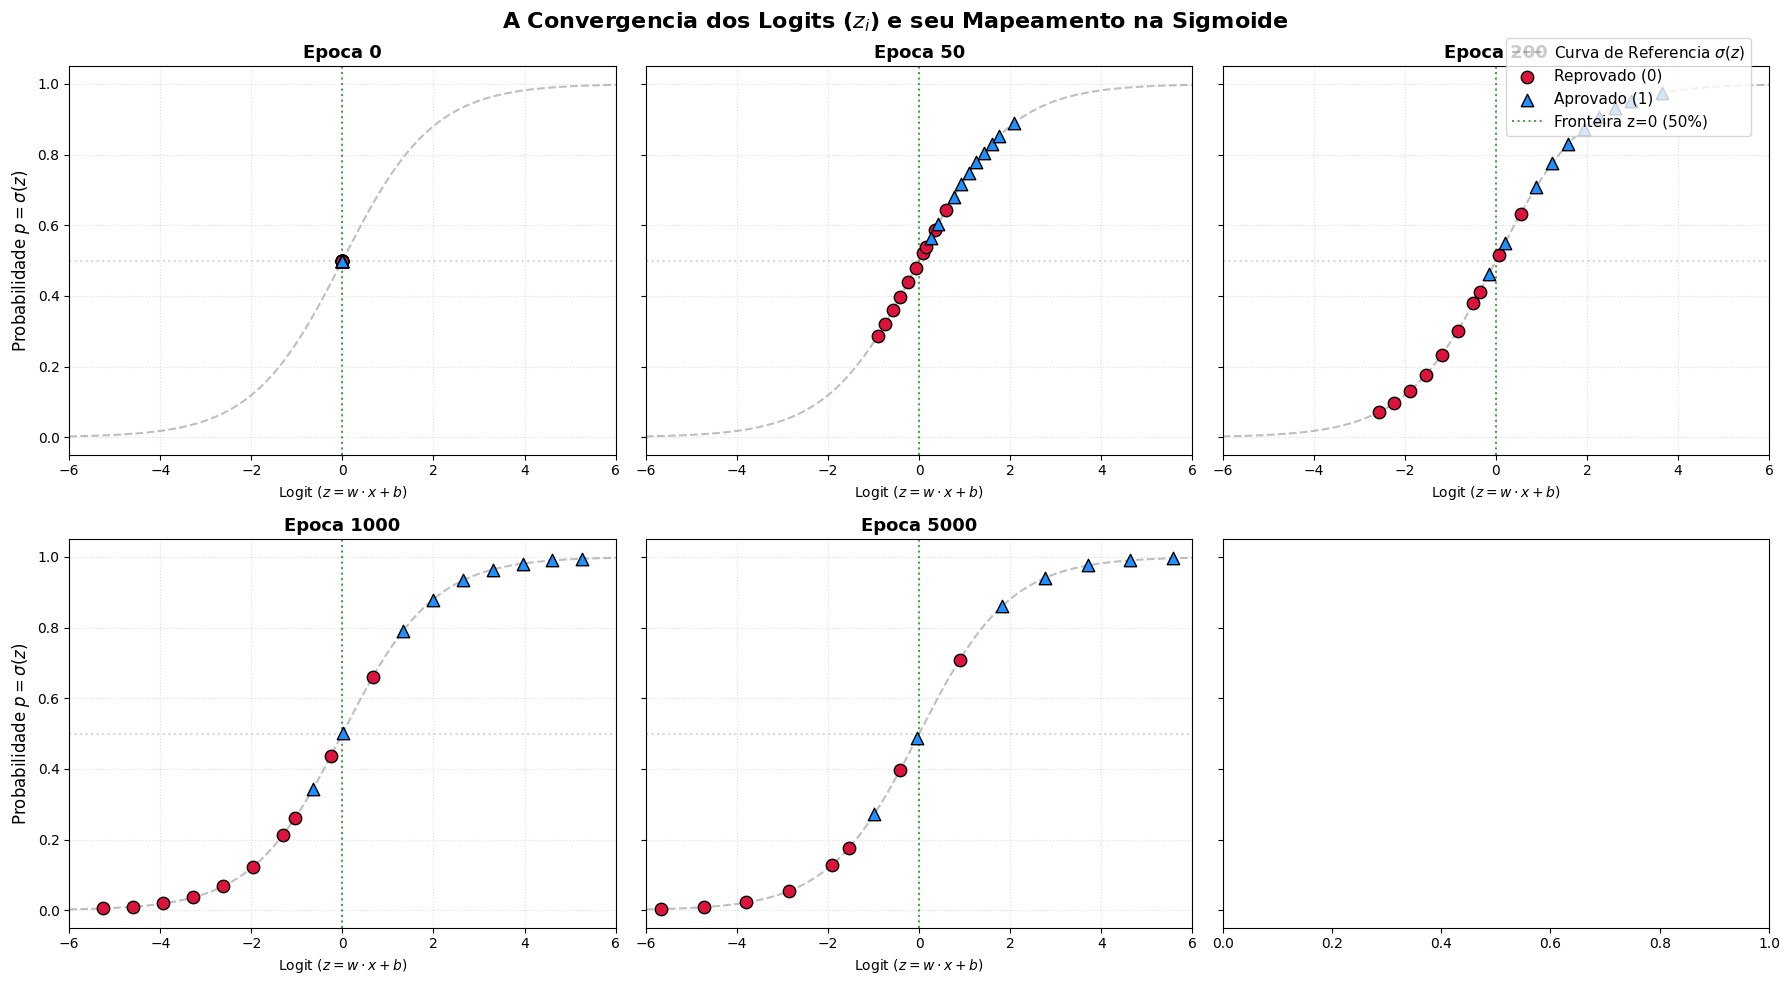

In [6]:
# Treinamento intermediário para registro do histórico
pesos_historico = []
epocas_registro = [0, 50, 200, 1000, 5000]

peso_temp = 0.0
bias_temp = 0.0
for epoca in range(1, 5001):
    if (epoca - 1) in epocas_registro:
        pesos_historico.append((epoca - 1, peso_temp, bias_temp))
        
    peso_temp, bias_temp = ml.gradient_descent_passo(X, y, taxa_aprendizado, peso_temp, bias_temp, modelo="logistica")

# Adiciona o estado final
pesos_historico.append((5000, peso_temp, bias_temp))

# Traçar o gráfico múltiplo com subplots usando strings raw (r"...") para evitar erros de escape
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.ravel()

# Curva sigmoide teórica de referência
z_ref = np.linspace(-6, 6, 200)
sig_ref = [alg.sigmoide(zi) for zi in z_ref]

for idx, (ep, w_ep, b_ep) in enumerate(pesos_historico):
    ax = axes[idx]
    
    # Calcula zi e probabilidade para cada ponto nesta época
    zi_pontos = [xi * w_ep + b_ep for xi in X]
    probas_pontos = [alg.sigmoide(zi) for zi in zi_pontos]
    
    # Desenha a curva teórica de referência em cinza com string raw
    ax.plot(z_ref, sig_ref, color='gray', linestyle='--', alpha=0.5, label=r'Curva de Referencia $\sigma(z)$' if idx == 0 else "")
    
    # Pontos reais classificados pelo y real
    for class_val, color, marker, label in [(0, 'crimson', 'o', 'Reprovado (0)'), (1, 'dodgerblue', '^', 'Aprovado (1)')]:
        x_c = [zi for zi, yi in zip(zi_pontos, y) if yi == class_val]
        y_c = [p for p, yi in zip(probas_pontos, y) if yi == class_val]
        ax.scatter(x_c, y_c, color=color, marker=marker, edgecolor='k', s=80, zorder=3,
                   label=label if idx == 0 else "")
        
    # Linha no zero (probabilidade = 0.5)
    ax.axvline(x=0.0, color='forestgreen', linestyle=':', alpha=0.8, label='Fronteira z=0 (50%)' if idx == 0 else "")
    ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.3)
    
    ax.set_title(f"Epoca {ep}", fontsize=13, fontweight='bold')
    ax.set_xlabel(r"Logit ($z = w \cdot x + b$)", fontsize=10)
    ax.set_xlim(-6, 6)
    ax.grid(True, linestyle=':', alpha=0.4)

axes[0].set_ylabel(r"Probabilidade $p = \sigma(z)$", fontsize=12)
axes[3].set_ylabel(r"Probabilidade $p = \sigma(z)$", fontsize=12)
fig.suptitle(r"A Convergencia dos Logits ($z_i$) e seu Mapeamento na Sigmoide", fontsize=16, y=0.98, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.98, 0.96), fontsize=11)
plt.tight_layout()
plt.show()

## 6. Avaliação do Modelo (Métricas da Biblioteca Local)

Agora, calculamos as métricas de desempenho utilizando as funções importadas diretamente da nossa biblioteca local `machine_learning.py`.
As previsões do modelo são geradas classificando como 1 os alunos com probabilidade $\ge 0.5$ e como 0 os demais.

In [7]:
# Gerar previsões binárias usando o método predict da classe
y_pred = modelo_logistica.predict(X)

# Obtendo a Matriz de Confusão diretamente da lib local
mc = ml.matriz_confusao(y, y_pred)

print("=== Matriz de Confusão (Biblioteca Local) ===")
print(f"                Previsão=0  Previsão=1")
print(f"Real=0 (Reprov)     {mc['VN']:2d}          {mc['FP']:2d}")
print(f"Real=1 (Aprov)      {mc['FN']:2d}          {mc['VP']:2d}")

=== Matriz de Confusão (Biblioteca Local) ===
                Previsão=0  Previsão=1
Real=0 (Reprov)      9           1
Real=1 (Aprov)       2           8


### Cálculo das Métricas de Classificação (Biblioteca Local)

As métricas foram todas implementadas na biblioteca local de forma 100% nativa em Python:

* **Acurácia:** `ml.acuracia(y_real, y_pred)`
* **Precisão:** `ml.precisao(y_real, y_pred)`
* **Revocação (Recall):** `ml.revocacao(y_real, y_pred)`
* **F1-Score:** `ml.f1_score(y_real, y_pred)`

In [8]:
acuracia_val = ml.acuracia(y, y_pred)
precisao_val = ml.precisao(y, y_pred)
recall_val = ml.revocacao(y, y_pred)
f1_val = ml.f1_score(y, y_pred)

print("=== Métricas de Desempenho (Biblioteca Local) ===")
print(f"Acurácia:  {acuracia_val * 100:.2f}%")
print(f"Precisão:  {precisao_val * 100:.2f}%")
print(f"Revocação: {recall_val * 100:.2f}%")
print(f"F1-Score:  {f1_val:.4f}")

=== Métricas de Desempenho (Biblioteca Local) ===
Acurácia:  85.00%
Precisão:  88.89%
Revocação: 80.00%
F1-Score:  0.8421


## 🎯 Conclusão

* Treinamos o modelo utilizando nossa biblioteca local.
* Avaliamos os resultados com métricas padrão da indústria, todas implementadas do zero de forma Pythônica e importadas para este notebook.